In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormaps
import matplotlib as mpl
import matplotlib.patches as patches
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams["font.size"] = 16
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 12

In [2]:
def get_kl_div(p,q):
    return p*np.log(p/q)

def gauss_dist(xs, mu, sigma=1.0):
    A = np.sqrt(2.0*np.pi*sigma**2)
    exp_func = np.exp(-(xs-mu)**2/(2.0*sigma**2))
    return exp_func/A

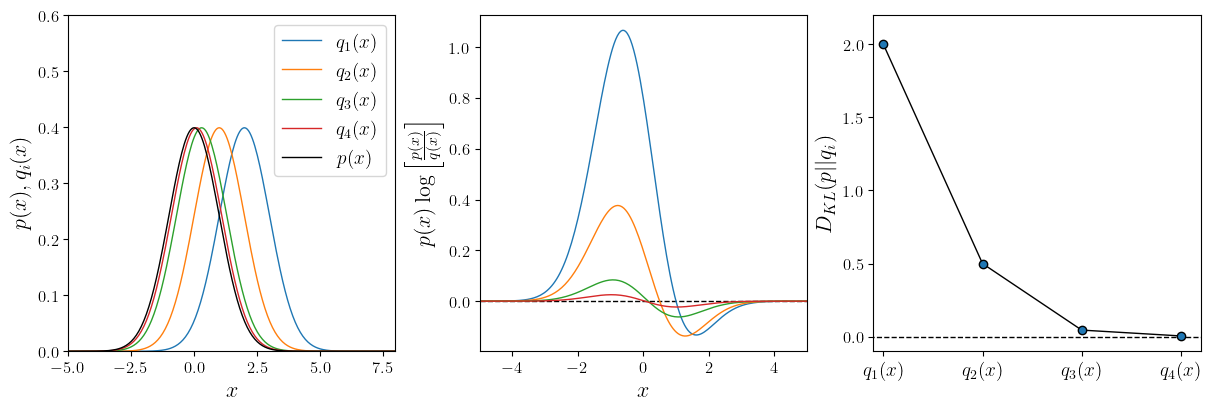

In [3]:
fig, axs = plt.subplots(1,3, figsize=(12,4), layout="constrained")
axs[0].set_ylim([0.0, 0.6])
axs[0].set_xlim([-5.0, 8.0])
axs[1].set_xlim([-5.0, 5.0])
axs[2].set_ylim([-0.1,2.2])
axs[2].set_xlim([-0.1,3.2])

axs[1].hlines(0,-5,5, colors="k", ls="--", lw=1)
axs[2].hlines(0,-2,5, colors="k", ls="--", lw=1, zorder=-2)

xs = np.linspace(-5, 20, 500)
p_x = gauss_dist(xs=xs, mu=0.0)
mus = np.array([2.0, 1.0, 0.3, 0.1])
colors = ["C0","C1", "C2", "C3", "C4"]
kl_divs = []
last_plot_labels = []
for i, mu, color in zip(range(len(mus)), mus, colors):
    q_dist = gauss_dist(xs=xs, mu=mu)
    kl_div_func = get_kl_div(p=p_x, q=q_dist)
    kl_div = np.trapezoid(kl_div_func, xs)
    kl_divs.append(kl_div)
    last_plot_label = f"$q_{i+1}(x)$"
    last_plot_labels.append(last_plot_label)
    axs[0].plot(xs, q_dist, color=color, label=last_plot_label, lw=1)
    axs[1].plot(xs, kl_div_func, color=color, lw=1)


axs[2].set_xticks([0,1,2,3], last_plot_labels, fontsize=14)
axs[0].set_xlabel(r"$x$")
axs[0].set_ylabel(r"$p(x), q_i(x)$")
axs[1].set_xlabel(r"$x$")
axs[0].plot(xs, p_x, c="k", label="$p(x)$",lw=1)
axs[2].plot([0,1,2,3], kl_divs, c="k", lw=1, zorder=-1)
axs[2].scatter([0,1,2,3], kl_divs, edgecolors="k")
axs[0].legend(fontsize=14)

axs[1].set_ylabel(r"$p(x) \log \left[ \frac{p(x)}{q(x)} \right]$")
axs[2].set_ylabel("$D_{KL}(p || q_i)$")
plt.savefig("kl_div.pdf", bbox_inches='tight')